## Guillespie Simulations for Regular hypergraph


This notebook genereated the stocastic simualtion used to create the phase diagram of SIS process in a regular hypegraph with uncorrelted cross-order correlation used in figure 2 of the paper 'Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import sys, os


In [3]:
sys.path.insert(1,'../Libraries/')

from Configurational_model_HO import* #one for the configurational mdoel and another
from Overlap_func import* #for calcualte overlap of higher order netowks
from HO_effective_degree import* #contains then necesaryt functions for effective hyperdegree

In [5]:
from datetime import datetime
start_time = datetime.now()


#N=500
N=1000
k1=5
k2=3
mu=1

lam1=2
lam2=5

beta1=lam1*mu/k1
beta2=lam2*mu/k2

iters=2
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=40

pairs= np.loadtxt(f'../data/higherorder_networkstructures/reg_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples = np.loadtxt(f'../data/higherorder_networkstructures/reg_triples_N{N}_k1{k1}_k2{k2}.txt', dtype=float).astype(int)

init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
times_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-4)

all_sim=[]
I=I_runs[0]

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


Duration: 0:00:05.597260


IndexError: list index out of range

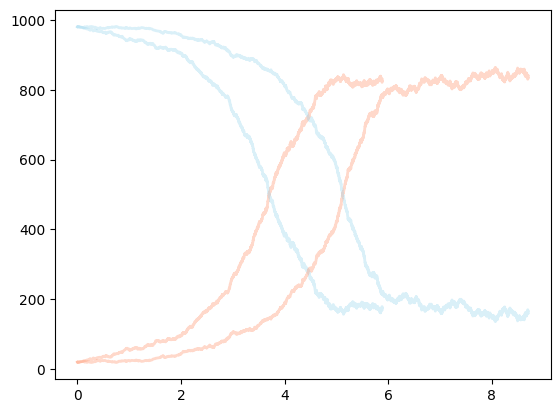

In [6]:
# plt.title(r'Regular $k_1=4, k_2=2$')

N=1000
k1=8
k2=4

for j in range (len(times_runs)):
    #data_sim=np.loadtxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}_{j}.txt')
    t,S_,I_=times_runs[j],S_runs[j],I_runs[j]
    plt.plot(t,I_,lw=2,color='coral', alpha=0.3)
    plt.plot(t,S_,lw=2,color='skyblue', alpha=0.3)



In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]
#N=500
N=1000
k1=5
k2=3
lam2=2.5
mu=1
beta2=lam2*mu/k2

iters=100
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=70


pairs= np.loadtxt(f'../data/higherorder_networkstructures/reg_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples = np.loadtxt(f'../data/higherorder_networkstructures/reg_triples_N{N}_k1{k1}_k2{k2}.txt', dtype=float).astype(int)

init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states1=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    Itimes_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-6)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        epidemic_size.append(np.mean(I[-100:]))
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states1.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))




/tmp/ipykernel_1326604/2862792498.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../Regular_structures/reg_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
/tmp/ipykernel_1326604/2862792498.py:26: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
    

Lambda=  0.001, Epidemic_size = 10.195135784591065, final time 5.549708516274827 
Lambda=  0.12338775510204081, Epidemic_size = 10.468443308098966, final time 5.549708516274827 
Lambda=  0.24577551020408162, Epidemic_size = 10.42645000267766, final time 5.549708516274827 
Lambda=  0.3681632653061224, Epidemic_size = 10.800858724576425, final time 5.549708516274827 
Lambda=  0.49055102040816323, Epidemic_size = 11.253033994150691, final time 5.549708516274827 
Lambda=  0.612938775510204, Epidemic_size = 11.491082574219298, final time 5.549708516274827 
Lambda=  0.7353265306122448, Epidemic_size = 11.182273471631845, final time 5.549708516274827 
Lambda=  0.8577142857142857, Epidemic_size = 11.04172233622048, final time 5.549708516274827 
Lambda=  0.9801020408163265, Epidemic_size = 10.255102584046515, final time 5.549708516274827 
Lambda=  1.1024897959183673, Epidemic_size = 9.946810458681082, final time 5.549708516274827 
Lambda=  1.224877551020408, Epidemic_size = 275.98919682539685, 

In [12]:
print(I_steady_states1)

[[10.0, 10.0, 10.0, 10.64, 10.0, 10.0, 10.478260869565217, 10.0, 10.0, 10.0, 10.91304347826087, 10.0, 10.24, 10.0, 10.0, 10.0, 10.0, 10.0, 10.391304347826088, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 11.862068965517242, 10.0, 10.0, 10.0, 10.91304347826087], [10.56, 10.91304347826087, 11.517241379310345, 10.0, 10.0, 10.0, 11.074074074074074, 11.36, 10.652173913043478, 10.0, 10.16, 10.0, 10.88, 10.0, 9.695652173913043, 10.0, 10.0, 9.782608695652174, 9.148148148148149, 10.0, 10.391304347826088, 10.0, 10.4, 10.24, 10.391304347826088, 9.814814814814815, 10.096774193548388, 10.391304347826088, 9.241379310344827, 9.88888888888889], [11.28, 11.68, 9.12, 10.565217391304348, 11.36, 9.347826086956522, 10.037037037037036, 9.28, 10.91304347826087, 9.869565217391305, 10.925925925925926, 9.193548387096774, 10.758620689655173, 10.64, 9.724137931034482, 10.565217391304348, 10.73913043478261, 10.88, 10.0, 11.448275862068966, 9.434782608695652, 10.043478260869565, 10.652173913043478, 10.0, 9.76, 10.4074074074

In [18]:
np.savetxt('../data/Phase_diagram/reg_I_steady_state1.txt',I_steady_states1)

In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]


#N=500
N=1000
k1=5
k2=3
lam2=2.5
mu=1
beta2=lam2*mu/k2

iters=100
num_inf=900
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=70


pairs= np.loadtxt(f'../data/higherorder_networkstructures/reg_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples = np.loadtxt(f'../data/higherorder_networkstructures/reg_triples_N{N}_k1{k1}_k2{k2}.txt', dtype=float).astype(int)



init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states2=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    Itimes_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-6)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        epidemic_size.append(np.mean(I[-100:]))
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states2.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))

end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))

In [ ]:
print(I_steady_states2)

[[28.24, 37.42, 39.66, 41.04, 40.88, 40.5, 39.28, 41.46, 42.52, 38.1, 38.34, 38.7, 42.4, 37.9, 38.18, 39.34, 39.86, 37.96, 37.7, 38.4, 32.04, 40.14, 43.64, 38.88, 37.78, 38.28, 41.66, 32.66, 43.02, 43.94, 44.52, 42.54, 35.0, 39.14, 38.74, 36.32, 33.58, 38.9, 26.44, 41.64, 44.2, 27.28, 46.32, 38.44, 36.12, 41.48, 45.16, 35.96, 33.98, 35.78, 38.14, 39.04, 39.1, 41.7, 35.96, 34.7, 39.8, 38.98, 35.6, 44.98, 38.34, 44.06, 39.22, 42.54, 38.44, 44.14, 34.58, 33.3, 38.0, 44.52, 36.8, 43.04, 43.08, 38.36, 41.04, 44.34, 44.36, 38.84, 46.54, 41.78, 40.86, 44.86, 35.88, 35.9, 35.86, 39.14, 41.44, 37.84, 44.46, 43.26, 40.82, 38.82, 39.04, 40.92, 44.98, 39.78, 38.86, 45.48, 41.88, 39.32], [36.8, 32.34, 36.5, 35.1, 39.9, 32.14, 37.98, 36.38, 35.52, 38.02, 27.66, 33.9, 34.24, 37.7, 41.06, 37.78, 41.2, 31.42, 31.68, 35.8, 36.1, 31.54, 31.42, 29.12, 35.06, 35.96, 32.58, 38.56, 30.4, 32.64, 33.48, 32.14, 37.92, 25.06, 37.44, 34.54, 36.7, 34.28, 36.44, 38.0, 30.02, 29.34, 34.42, 35.32, 34.56, 31.74, 30.7,

In [35]:
I_steady_states2 = [[28.24, 37.42, 39.66, 41.04, 40.88, 40.5, 39.28, 41.46, 42.52, 38.1, 38.34, 38.7, 42.4, 37.9, 38.18, 39.34, 39.86, 37.96, 37.7, 38.4, 32.04, 40.14, 43.64, 38.88, 37.78, 38.28, 41.66, 32.66, 43.02, 43.94, 44.52, 42.54, 35.0, 39.14, 38.74, 36.32, 33.58, 38.9, 26.44, 41.64, 44.2, 27.28, 46.32, 38.44, 36.12, 41.48, 45.16, 35.96, 33.98, 35.78, 38.14, 39.04, 39.1, 41.7, 35.96, 34.7, 39.8, 38.98, 35.6, 44.98, 38.34, 44.06, 39.22, 42.54, 38.44, 44.14, 34.58, 33.3, 38.0, 44.52, 36.8, 43.04, 43.08, 38.36, 41.04, 44.34, 44.36, 38.84, 46.54, 41.78, 40.86, 44.86, 35.88, 35.9, 35.86, 39.14, 41.44, 37.84, 44.46, 43.26, 40.82, 38.82, 39.04, 40.92, 44.98, 39.78, 38.86, 45.48, 41.88, 39.32], [36.8, 32.34, 36.5, 35.1, 39.9, 32.14, 37.98, 36.38, 35.52, 38.02, 27.66, 33.9, 34.24, 37.7, 41.06, 37.78, 41.2, 31.42, 31.68, 35.8, 36.1, 31.54, 31.42, 29.12, 35.06, 35.96, 32.58, 38.56, 30.4, 32.64, 33.48, 32.14, 37.92, 25.06, 37.44, 34.54, 36.7, 34.28, 36.44, 38.0, 30.02, 29.34, 34.42, 35.32, 34.56, 31.74, 30.7, 41.76, 35.12, 39.08, 33.3, 39.92, 36.64, 34.02, 38.78, 33.76, 30.7, 30.48, 32.88, 34.2, 28.2, 32.14, 37.2, 28.46, 35.94, 37.62, 27.8, 36.3, 30.54, 38.62, 31.0, 29.98, 36.8, 29.3, 34.2, 28.36, 37.82, 40.66, 26.26, 33.8, 36.6, 32.08, 39.78, 36.06, 33.98, 35.28, 35.74, 34.3, 31.26, 33.82, 33.3, 32.06, 32.84, 36.16, 32.9, 37.08, 30.54, 34.8, 29.2, 33.0], [30.1, 26.14, 29.88, 24.9, 27.54, 24.64, 25.84, 24.5, 26.4, 31.22, 33.92, 34.24, 27.18, 28.54, 31.58, 24.94, 26.3, 29.72, 30.84, 29.66, 26.28, 20.74, 24.94, 23.74, 28.7, 30.86, 29.06, 33.8, 26.98, 26.32, 32.78, 27.24, 28.98, 28.0, 25.06, 35.28, 32.8, 30.54, 28.0, 28.02, 27.74, 31.0, 29.88, 28.54, 29.98, 27.24, 23.54, 22.98, 24.58, 35.62, 36.96, 25.88, 30.38, 34.52, 25.8, 26.1, 29.58, 26.26, 28.26, 23.72, 27.08, 28.18, 27.94, 31.34, 24.62, 24.8, 15.76, 34.46, 26.14, 30.58, 19.14, 26.8, 29.16, 32.36, 32.84, 26.06, 29.44, 28.86, 23.94, 24.52, 33.98, 32.86, 28.08, 30.92, 31.46, 27.94, 25.28, 30.68, 29.58, 31.44, 26.24, 26.28, 34.2, 27.76, 27.66, 31.62, 25.94, 17.42, 25.54, 30.24], [25.56, 19.66, 26.38, 17.78, 20.64, 22.9, 28.82, 24.92, 27.16, 27.46, 28.8, 12.94, 23.06, 21.48, 13.7, 22.66, 18.6, 26.4, 23.8, 27.62, 25.1, 23.28, 27.58, 23.68, 19.32, 22.14, 23.66, 15.1, 21.4, 29.8, 22.24, 22.84, 26.8, 29.12, 23.28, 16.0, 19.42, 22.7, 25.04, 22.46, 23.36, 27.42, 25.12, 15.4, 20.6, 18.82, 20.46, 24.98, 22.32, 17.98, 25.66, 24.14, 27.08, 24.22, 20.48, 22.96, 27.36, 21.74, 24.6, 31.86, 26.74, 24.32, 19.34, 18.7, 28.7, 15.04, 27.66, 24.64, 26.26, 19.3, 20.9, 29.74, 30.44, 20.68, 18.24, 26.38, 20.26, 32.68, 22.56, 25.34, 24.76, 33.64, 19.5, 21.58, 23.3, 26.3, 23.58, 21.74, 21.22, 25.98, 20.88, 22.4, 15.6, 14.78, 20.02, 23.06, 23.62, 28.02, 23.1, 22.34], [19.08, 22.32, 20.34, 22.0, 10.6, 20.22, 12.68, 19.2, 15.28, 19.96, 20.84, 16.18, 21.64, 12.6, 14.48, 21.36, 19.4, 20.32, 14.2, 12.22, 20.06, 19.98, 24.82, 18.88, 11.62, 29.02, 21.7, 25.82, 18.08, 17.34, 19.62, 22.38, 10.96, 15.6, 16.28, 24.68, 17.6, 26.64, 17.74, 20.28, 22.86, 18.9, 23.26, 14.26, 21.9, 15.16, 23.34, 14.64, 16.84, 20.0, 22.56, 17.92, 21.22, 18.32, 18.6, 18.4, 14.76, 22.92, 20.16, 16.52, 20.78, 15.62, 25.4, 30.46, 27.84, 27.88, 24.14, 24.7, 21.0, 13.16, 24.22, 13.12, 20.64, 14.42, 17.68, 19.84, 12.88, 21.4, 19.64, 26.72, 21.42, 25.72, 18.04, 16.82, 12.6, 14.82, 19.24, 19.98, 21.14, 21.34, 22.54, 28.1, 21.44, 19.42, 23.86, 17.06, 12.52, 10.32, 21.44, 13.32], [26.36, 20.74, 29.06, 17.82, 17.82, 16.62, 16.84, 16.52, 13.7, 18.74, 12.92, 17.42, 22.08, 12.34, 17.92, 25.64, 27.64, 14.2, 13.98, 18.48, 11.74, 11.72, 25.32, 12.88, 20.92, 10.36, 18.78, 10.68, 15.28, 14.2, 21.48, 14.42, 13.34, 24.62, 12.54, 11.52, 18.32, 20.56, 23.34, 16.26, 12.48, 18.7, 19.28, 15.26, 13.66, 5.78, 16.2, 16.78, 15.02, 16.2, 18.6, 9.5, 16.58, 13.58, 20.08, 17.84, 16.68, 10.72, 9.26, 8.44, 14.76, 14.38, 18.16, 6.84, 11.92, 13.88, 18.26, 19.26, 13.8, 10.1, 21.3, 24.0, 25.98, 14.44, 13.78, 15.24, 23.3, 16.26, 21.08, 14.06, 13.94, 15.7, 8.0, 16.42, 11.3, 19.6, 18.1, 16.4, 6.74, 14.64, 14.7, 17.12, 19.32, 16.1, 8.16, 19.06, 10.06, 10.96, 15.64, 13.56], [14.18, 11.04, 9.78, 14.06, 13.58, 13.32, 13.94, 13.66, 9.86, 18.8, 17.94, 15.4, 12.68, 20.64, 11.34, 11.1, 12.52, 16.08, 12.34, 25.14, 15.56, 16.1, 10.7, 14.22, 7.84, 13.42, 9.44, 12.56, 9.56, 6.8, 14.48, 10.98, 6.82, 18.18, 11.16, 9.56, 16.68, 10.74, 13.96, 5.36, 17.22, 18.9, 17.12, 17.92, 12.86, 13.26, 15.64, 14.66, 21.28, 19.9, 18.72, 14.68, 19.34, 14.78, 12.62, 16.18, 10.04, 16.88, 16.8, 13.26, 17.4, 13.16, 19.38, 14.2, 7.04, 17.04, 14.82, 14.46, 18.72, 18.6, 16.52, 14.58, 20.94, 9.84, 10.54, 7.44, 9.04, 15.4, 13.84, 23.5, 14.46, 16.62, 15.32, 7.36, 9.06, 19.4, 13.1, 9.98, 13.74, 13.9, 12.96, 14.94, 12.2, 7.32, 13.72, 9.8, 13.9, 11.38, 15.14, 9.46], [11.5, 19.3, 9.58, 8.2, 9.46, 19.34, 14.18, 20.56, 13.36, 5.62, 13.82, 16.08, 15.12, 10.3, 8.24, 8.96, 10.06, 13.0, 15.84, 11.94, 15.2, 15.16, 10.2, 5.0, 10.3, 13.24, 15.54, 7.78, 9.96, 11.26, 4.9, 11.62, 10.28, 12.86, 11.56, 11.12, 17.16, 13.16, 16.42, 12.46, 12.96, 10.04, 11.86, 14.4, 13.98, 9.62, 15.34, 13.8, 11.26, 8.98, 8.92, 16.34, 15.5, 13.18, 14.8, 15.6, 14.82, 7.36, 10.16, 12.48, 15.02, 11.34, 9.7, 13.84, 13.2, 15.3, 6.48, 16.76, 12.0, 7.8, 8.46, 10.76, 9.7, 10.22, 13.68, 12.76, 10.94, 17.0, 10.12, 14.58, 15.68, 19.62, 13.5, 7.1, 14.1, 14.64, 10.84, 12.52, 18.56, 5.18, 8.9, 9.02, 17.54, 12.4, 9.84, 12.32, 7.74, 17.48, 15.18, 16.38], [383.3, 425.34, 436.56, 471.28, 467.64, 438.82, 337.92, 434.48, 398.22, 459.78, 476.0, 454.14, 479.06, 492.62, 399.58, 461.6, 536.32, 514.04, 376.48, 514.46, 445.3, 437.56, 487.54, 437.0, 464.04, 464.68, 463.64, 436.1, 505.3, 509.04, 499.46, 446.68, 422.88, 425.38, 408.94, 490.26, 382.0, 504.78, 432.5, 396.28, 411.98, 417.82, 447.38, 452.88, 389.82, 447.9, 435.1, 411.86, 519.42, 466.66, 459.72, 498.72, 517.74, 477.16, 401.82, 395.88, 440.9, 393.28, 473.8, 317.14, 459.52, 462.78, 451.42, 476.0, 380.84, 456.84, 395.7, 429.3, 423.42, 409.64, 429.36, 445.98, 455.06, 399.38, 375.02, 457.48, 470.28, 446.0, 464.08, 522.2, 398.08, 431.58, 384.74, 465.76, 455.12, 483.08, 471.96, 461.2, 396.82, 475.78, 490.22, 514.86, 438.1, 437.92, 449.38, 449.98, 413.04, 442.0, 449.9, 347.64], [502.26, 504.82, 505.62, 476.8, 562.34, 513.8, 587.02, 575.26, 543.96, 544.86, 560.36, 481.22, 507.48, 534.88, 491.44, 521.64, 458.48, 518.54, 513.46, 503.26, 539.3, 510.7, 522.14, 529.04, 492.08, 569.12, 514.92, 511.18, 595.14, 477.98, 509.36, 511.96, 498.3, 528.54, 499.58, 459.98, 578.16, 475.6, 518.04, 557.34, 540.24, 510.0, 506.14, 496.04, 458.48, 549.16, 524.36, 524.4, 536.02, 506.04, 587.14, 467.32, 503.72, 556.62, 559.44, 571.76, 567.68, 551.2, 498.18, 523.58, 550.98, 538.6, 492.22, 557.92, 564.74, 511.7, 468.5, 518.84, 514.88, 527.42, 544.04, 514.32, 477.36, 502.46, 545.48, 579.68, 534.02, 504.72, 544.08, 522.72, 519.84, 500.84, 501.5, 522.24, 485.16, 533.24, 525.1, 492.28, 572.42, 484.62, 565.62, 492.82, 551.16, 559.28, 554.8, 521.12, 549.68, 471.04, 495.42, 519.58], [534.54, 583.28, 583.58, 547.28, 529.76, 550.02, 611.64, 596.2, 590.64, 555.06, 606.02, 580.8, 634.54, 548.28, 569.08, 565.96, 586.06, 594.22, 569.04, 582.98, 576.7, 547.76, 591.38, 532.08, 586.68, 590.18, 586.04, 640.0, 594.1, 568.32, 582.2, 571.2, 541.76, 618.28, 572.54, 564.08, 565.1, 585.94, 605.38, 615.82, 616.14, 561.88, 539.1, 636.7, 590.38, 587.76, 520.6, 535.22, 611.88, 506.82, 593.96, 597.02, 598.94, 568.22, 557.6, 599.74, 585.14, 593.72, 584.2, 588.9, 567.92, 613.44, 532.46, 614.94, 554.68, 606.4, 528.7, 596.26, 599.94, 622.9, 623.72, 565.26, 627.5, 615.26, 580.44, 566.36, 603.16, 618.82, 536.48, 572.54, 559.7, 585.8, 571.2, 562.8, 577.46, 550.02, 558.02, 626.12, 585.52, 566.88, 573.0, 596.66, 568.22, 577.06, 551.98, 516.84, 528.98, 565.4, 581.48, 538.24], [631.22, 584.6, 629.94, 650.82, 630.06, 605.92, 599.64, 620.3, 598.78, 637.98, 622.12, 634.8, 606.64, 580.42, 646.06, 593.44, 611.56, 562.12, 593.92, 594.28, 616.16, 635.68, 598.02, 622.48, 666.56, 636.58, 649.38, 563.94, 629.88, 644.9, 648.46, 614.28, 584.02, 642.6, 628.44, 583.02, 603.94, 632.08, 592.64, 596.26, 579.14, 647.26, 611.2, 585.54, 642.86, 573.92, 617.58, 651.3, 612.96, 565.78, 595.42, 593.92, 580.72, 634.78, 648.68, 579.92, 643.44, 606.08, 621.16, 666.18, 595.76, 604.02, 613.6, 606.8, 631.86, 615.62, 613.04, 639.48, 618.94, 601.74, 597.74, 622.14, 551.16, 608.54, 551.0, 603.64, 618.34, 622.64, 589.94, 647.64, 563.0, 632.06, 615.22, 622.36, 611.9, 614.68, 574.54, 660.46, 611.56, 629.98, 661.72, 600.88, 657.44, 603.78, 644.44, 636.2, 613.16, 591.68, 644.92, 601.0], [659.0, 703.44, 627.36, 604.98, 646.9, 622.2, 602.86, 626.66, 663.16, 630.16, 601.58, 660.56, 717.7, 654.26, 652.5, 637.72, 626.12, 637.74, 613.3, 655.26, 667.54, 643.5, 636.32, 649.14, 633.84, 629.68, 645.72, 634.3, 678.08, 648.02, 653.8, 649.16, 669.46, 652.28, 661.46, 682.72, 630.74, 690.32, 631.62, 655.74, 648.2, 659.96, 639.14, 635.7, 615.1, 619.62, 637.8, 657.82, 624.2, 662.02, 637.98, 671.76, 601.12, 628.18, 670.84, 619.78, 633.98, 630.74, 653.64, 628.0, 623.66, 615.62, 631.7, 610.34, 637.32, 633.86, 648.38, 636.5, 650.58, 651.14, 670.74, 697.96, 636.64, 678.36, 640.44, 645.32, 665.9, 624.7, 639.6, 665.06, 669.4, 648.76, 639.96, 633.0, 655.14, 633.26, 662.74, 669.76, 646.78, 592.64, 625.28, 654.28, 588.88, 672.5, 662.44, 664.2, 653.1, 676.16, 648.94, 613.3], [699.54, 652.86, 631.66, 640.92, 650.5, 671.94, 672.98, 700.3, 658.66, 656.46, 659.8, 684.2, 702.7, 662.36, 693.14, 657.74, 727.52, 644.9, 681.76, 649.68, 661.22, 694.44, 689.96, 629.92, 706.18, 666.74, 636.28, 679.2, 648.06, 685.18, 658.56, 668.12, 680.78, 697.56, 652.78, 672.7, 654.44, 660.9, 625.44, 642.6, 694.14, 640.76, 626.46, 697.3, 670.64, 704.96, 661.38, 668.84, 639.18, 668.86, 659.96, 664.78, 671.3, 665.48, 680.22, 652.38, 655.98, 699.72, 676.3, 682.06, 647.5, 669.9, 635.24, 668.0, 664.44, 700.58, 636.78, 674.52, 643.46, 644.76, 661.72, 676.88, 664.56, 657.98, 673.38, 652.5, 647.66, 644.08, 667.48, 658.54, 650.88, 688.7, 662.26, 664.94, 693.36, 654.72, 671.54, 664.38, 702.04, 662.38, 654.54, 656.32, 684.44, 635.3, 678.44, 677.72, 684.76, 692.5, 665.9, 710.04], [672.84, 683.64, 673.22, 696.44, 678.56, 698.14, 670.52, 672.28, 670.6, 668.12, 700.54, 642.76, 688.74, 682.76, 703.74, 705.46, 695.5, 701.6, 701.98, 665.66, 645.24, 700.06, 711.2, 664.7, 665.22, 704.04, 660.62, 646.44, 688.98, 746.6, 686.38, 705.28, 674.52, 693.1, 704.46, 701.96, 650.44, 698.24, 683.56, 710.18, 673.18, 682.56, 700.36, 702.34, 726.54, 673.58, 669.56, 723.88, 669.12, 687.22, 673.96, 727.72, 662.54, 686.12, 677.08, 667.6, 682.44, 698.6, 688.14, 669.22, 697.96, 716.5, 695.44, 691.9, 691.18, 684.36, 665.74, 691.4, 675.44, 683.42, 711.9, 672.22, 671.54, 654.02, 709.7, 684.62, 692.88, 709.68, 682.08, 681.94, 698.86, 666.54, 704.54, 696.76, 688.26, 677.82, 675.64, 711.78, 702.12, 705.28, 677.88, 704.0, 670.84, 685.04, 658.96, 693.62, 668.64, 671.18, 694.34, 697.5], [700.82, 679.88, 712.0, 694.24, 725.56, 706.6, 684.58, 690.68, 686.58, 665.82, 707.7, 697.48, 700.04, 716.54, 738.64, 683.56, 708.84, 730.08, 694.28, 712.7, 683.66, 684.52, 674.94, 710.08, 700.52, 719.4, 699.38, 674.94, 727.62, 675.36, 709.44, 683.02, 680.66, 717.66, 688.66, 684.4, 680.76, 663.14, 706.46, 677.54, 716.8, 726.3, 683.22, 703.72, 665.0, 706.48, 680.64, 700.5, 723.18, 723.34, 690.68, 702.66, 695.98, 703.62, 717.28, 678.12, 707.86, 723.6, 739.68, 684.1, 699.7, 718.76, 700.2, 695.56, 655.08, 705.6, 718.22, 707.24, 683.24, 705.18, 690.14, 701.72, 726.6, 719.78, 700.26, 679.46, 691.02, 710.5, 699.14, 706.34, 683.22, 714.74, 685.08, 736.4, 712.4, 707.28, 727.74, 720.28, 699.88, 696.24, 740.78, 685.9, 691.94, 712.76, 741.4, 702.06, 658.38, 681.14, 683.5, 698.94], [740.64, 738.58, 689.7, 747.84, 700.0, 727.32, 709.3, 735.72, 701.3, 713.36, 724.96, 719.02, 700.84, 730.5, 717.48, 728.94, 736.54, 704.86, 733.72, 711.42, 742.42, 723.04, 725.82, 721.52, 709.22, 696.8, 745.6, 724.04, 702.56, 704.86, 698.3, 673.38, 722.74, 731.54, 708.52, 694.14, 703.66, 709.32, 719.44, 752.18, 674.88, 728.94, 736.62, 697.48, 711.78, 722.04, 707.72, 698.64, 705.56, 727.1, 714.08, 740.6, 702.32, 712.26, 715.36, 704.72, 694.1, 730.54, 726.58, 732.8, 698.68, 722.2, 737.52, 715.24, 720.88, 720.44, 722.58, 704.8, 741.68, 736.3, 702.4, 714.84, 696.06, 692.02, 733.1, 705.42, 706.78, 710.26, 674.28, 736.06, 736.14, 702.28, 697.2, 728.48, 715.5, 695.98, 694.2, 679.2, 699.74, 719.88, 704.96, 691.02, 701.54, 747.82, 727.44, 727.82, 711.66, 727.4, 734.1, 743.04]]

In [36]:
np.savetxt('../data/Phase_diagram/reg_I_steady_state2.txt',I_steady_states2)